### 0. ライブラリのインポート

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import pickle

In [8]:
from pathlib import Path

### 1. データの取得と前処理

In [12]:
google = yf.download(tickers="GOOGL", start="2004-08-19", end="2019-12-19", interval="1d")

C:\Users\togen\AppData\Local\Temp\ipykernel_28640\2742358199.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  google = yf.download(tickers="GOOGL", start="2004-08-19", end="2019-12-19", interval="1d")
[*********************100%***********************]  1 of 1 completed


In [13]:
nke = yf.download(tickers="NKE", start="2010-01-04", end="2019-12-19", interval="1d")

C:\Users\togen\AppData\Local\Temp\ipykernel_28640\3323067095.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nke = yf.download(tickers="NKE", start="2010-01-04", end="2019-12-19", interval="1d")
[*********************100%***********************]  1 of 1 completed


In [14]:
google.head()

Price,Close,High,Low,Open,Volume
Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
Date,,,,,
2004-08-19,2.493811,2.586266,2.384952,2.485361,893181924
2004-08-20,2.691894,2.711032,2.497787,2.510463,456686856
2004-08-23,2.718985,2.820388,2.710286,2.752538,365122512
2004-08-24,2.606397,2.773663,2.574088,2.764715,304946748
2004-08-25,2.634483,2.684190,2.581793,2.608635,183772044


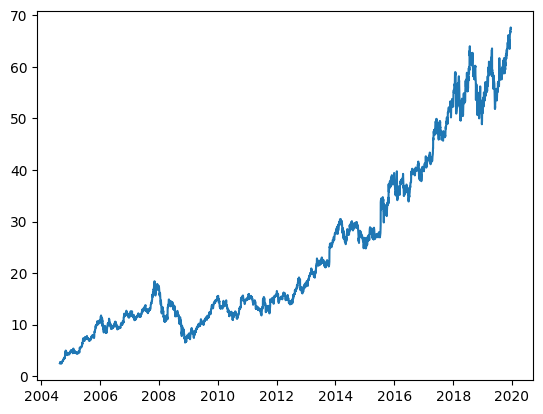

In [15]:
plt.plot(google["Open"])
plt.show()

In [16]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_google = scaler.fit_transform(google[["Open"]])
scaled_nke = scaler.fit_transform(nke[["Open"]])

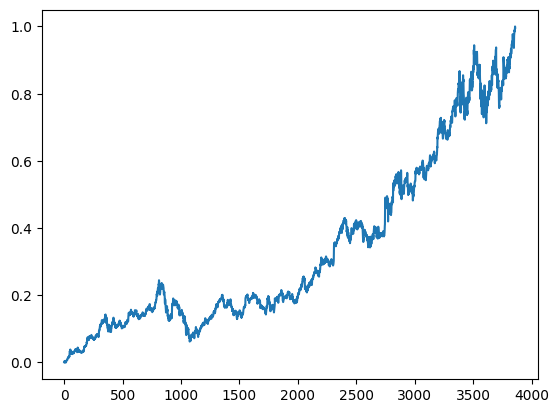

In [17]:
plt.plot(scaled_google)
plt.show()

In [18]:
look_back = 60  # 過去60日から次の日を予測

# データ準備
X, y = [], []
for i in range(look_back, len(scaled_google)):
    X.append(scaled_google[i-look_back:i, 0])  # 直近60日のデータ
    y.append(scaled_google[i, 0])              # 翌日

X, y = np.array(X), np.array(y)

# 学習データ・テストデータに分割
train_range = int(len(X) * 0.8)
X_train, X_test = X[:train_range], X[train_range-look_back:]
y_train, y_test = y[:train_range], y[train_range-look_back:]

# LSTM用に3次元化
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test  = np.reshape(X_test,  (X_test.shape[0],  X_test.shape[1],  1))

print(X_train.shape)  # 例: (2000, 60, 1)

(3040, 60, 1)


### 2. 簡易的なLSTMモデルを構築

In [97]:
epochs = 30

In [98]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=1))

model.compile(optimizer="adam", loss="mean_squared_error")
model.fit(X_train, y_train, epochs=epochs, batch_size=32)

Epoch 1/30


c:\Users\Ito Yuki\research_using_uv-main\research_using_uv-main\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0044
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 4.3396e-04
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 3.5802e-04
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 3.3990e-04
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 3.5453e-04
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 3.2128e-04
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 3.4772e-04
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 2.6613e-04
Epoch 9/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 3.0053e-04
Epoch 10/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 2.8330e-04
Epoch 11/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 2.8942e-04
Epoch 12/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 2.9632e-04
Epoch 13/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 2.3461e-04
Epoch 14/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 2.4875e-04
Epoch 15/30
95/95 ━━━━━━━━━━━━

### 3. 予測結果

[WindowsPath('../model/simple_LSTM/GOOGL/simple_LSTM_10.pkl'), WindowsPath('../model/simple_LSTM/GOOGL/simple_LSTM_100.pkl'), WindowsPath('../model/simple_LSTM/GOOGL/simple_LSTM_20.pkl'), WindowsPath('../model/simple_LSTM/GOOGL/simple_LSTM_30.pkl'), WindowsPath('../model/simple_LSTM/GOOGL/simple_LSTM_40.pkl'), WindowsPath('../model/simple_LSTM/GOOGL/simple_LSTM_50.pkl'), WindowsPath('../model/simple_LSTM/GOOGL/simple_LSTM_60.pkl'), WindowsPath('../model/simple_LSTM/GOOGL/simple_LSTM_70.pkl'), WindowsPath('../model/simple_LSTM/GOOGL/simple_LSTM_80.pkl'), WindowsPath('../model/simple_LSTM/GOOGL/simple_LSTM_90.pkl')]
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


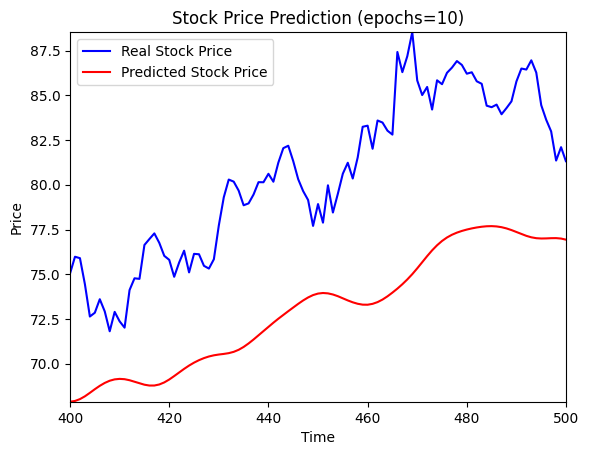

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


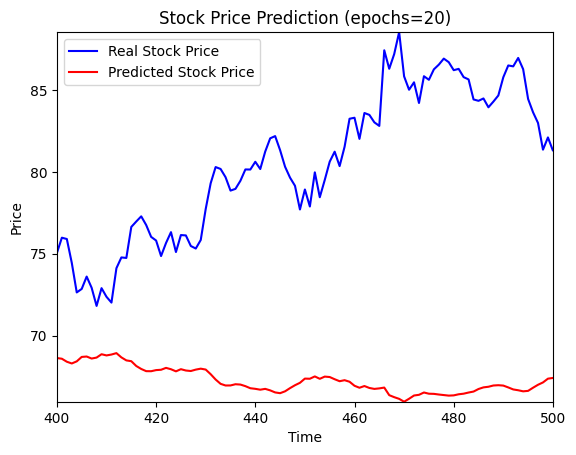

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


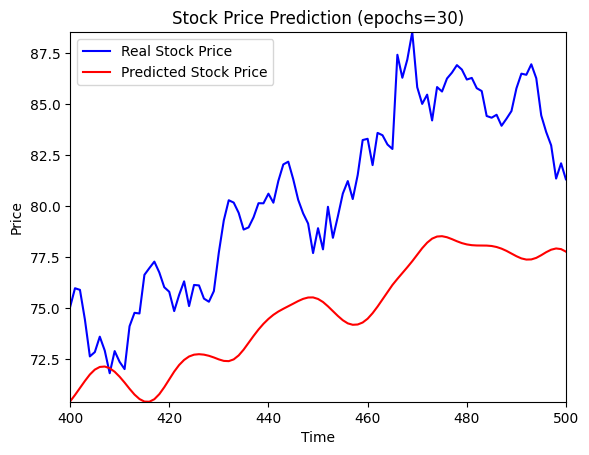

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


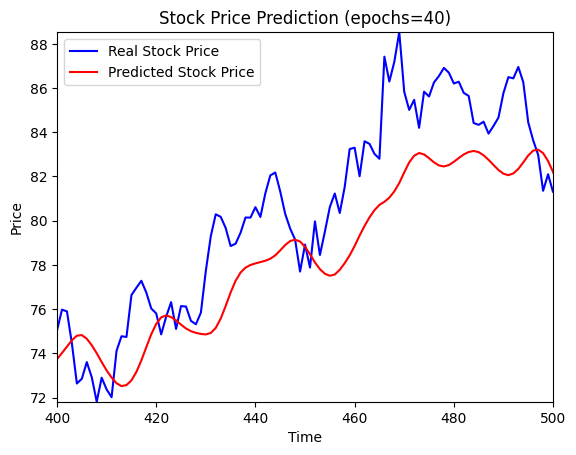

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


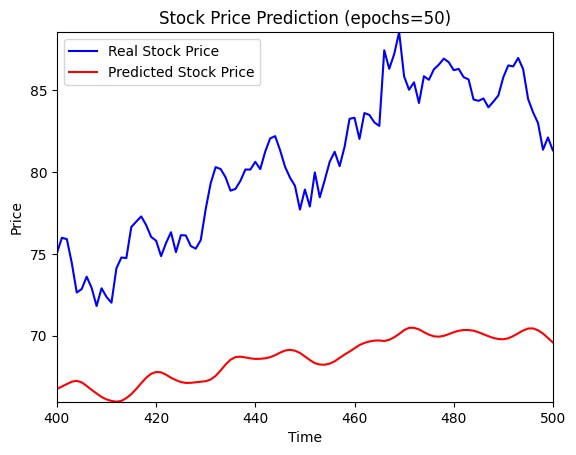

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


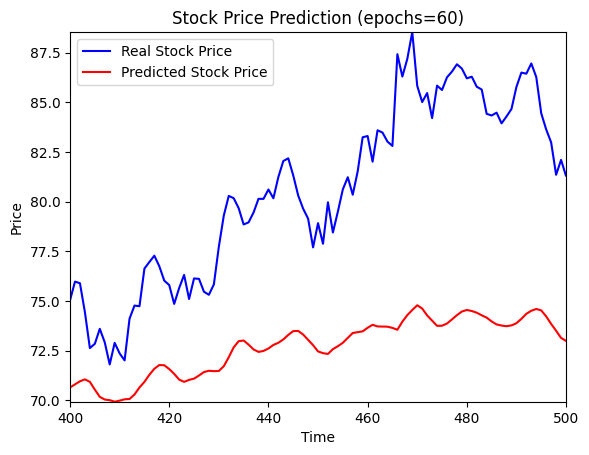

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


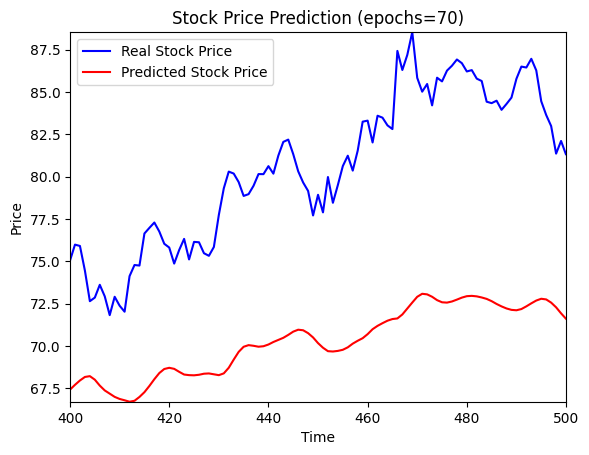

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


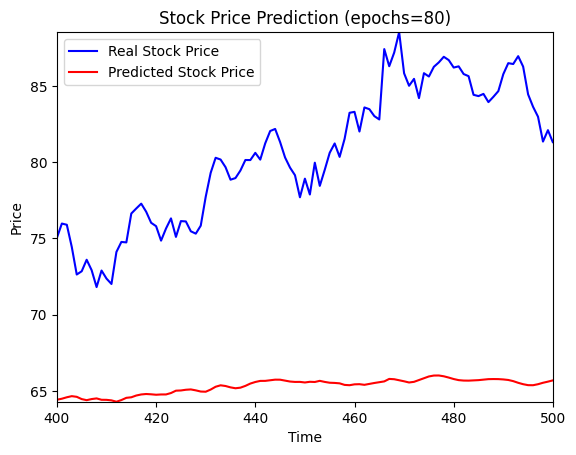

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


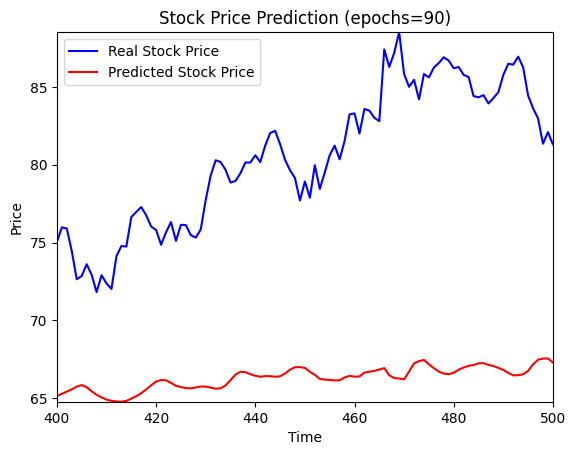

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


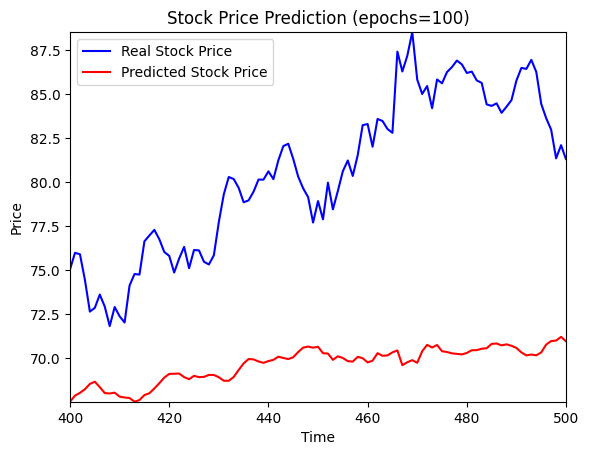

In [21]:
models = [model_path for model_path in Path('../model/simple_LSTM/GOOGL/').rglob('.') if model_path.suffix == '.pkl'] # model\simple_LSTM\GOOGL\simple_LSTM_10.pkl
models.sort()
print(models)

for i, model_path in enumerate(models):
    model = None
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
        epochs = (i + 1) * 10

    title = 'Stock Price Prediction (epochs={})'.format(epochs)
    predicted = model.predict(X_test)
    # y_test = y_test.reshape(y_test.shape[0], y_test.shape[1])
    y_test_originnal_scaled = scaler.inverse_transform(y_test.reshape(y_test.shape[0], 1))
    predicted_originnal_scaled = scaler.inverse_transform(predicted)
    # plt.plot(google["Open"], color='green', label='Real Stock Price')
    lower_ylim = min(y_test_originnal_scaled[~np.isnan(y_test_originnal_scaled)][400:500].min(), predicted_originnal_scaled[~np.isnan(predicted_originnal_scaled)][400:500].min())
    upper_ylim = max(y_test_originnal_scaled[~np.isnan(y_test_originnal_scaled)][400:500].max(), predicted_originnal_scaled[~np.isnan(predicted_originnal_scaled)][400:500].max())
    plt.plot(y_test_originnal_scaled, color='blue', label='Real Stock Price')
    plt.plot(predicted_originnal_scaled, color='red', label='Predicted Stock Price')
    plt.title(title)
    plt.xlim(400, 500)
    plt.ylim(lower_ylim, upper_ylim)
    plt.xlabel('Time')
    plt.ylabel('Price')
    plt.savefig('../images/simple_LSTM/GOOGL/partial_zoom/' + title + '.png') # images\simple_LSTM\GOOGL
    plt.legend()
    plt.show()

In [ ]:
# with open(f"../model/simple_LSTM_{epochs}.pkl", "wb") as f:
#     pickle.dump(model, f)